<a href="https://colab.research.google.com/github/VladLoPG/neural_networks/blob/main/hw8_code_reviewer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain_groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.1 MB/s eta 0:00:00


In [ ]:
from langchain_groq import ChatGroq
from datetime import datetime

In [ ]:
class Agent:
    def __init__(self, name, role, api_key, model="llama-3.1-8b-instant"):
        self.name = name
        self.role = role
        self.llm = ChatGroq(
            temperature=0.7,
            model_name=model,
            groq_api_key=api_key,
            max_tokens=1000
        )

    def execute(self, task, context=""):
        prompt = f"""
ROLE: You are {self.name}, {self.role}
CONTEXT: {context}
TASK: {task}

Requirements:
1. Use English
2. Properly format your answer using markdown
3. Be informative and up to the point

Answer:
"""
        response = self.llm.invoke(prompt)
        return response.content

In [ ]:
class Proxy:
  '''
  Класс принимает агентов, их задачи и код для ревью
  '''
  def __init__(self, agents, tasks, code):
    self.agents = agents
    self.tasks = tasks
    self.code = code
    self.results = {}

  def kickoff(self):
    for i, (agent, task_desc) in enumerate(zip(self.agents, self.tasks), 1):
      print(f"[TASK {i}/{len(self.tasks)}] {agent.name}")
      print(f"  Description: {task_desc}")
      if agent.name == 'Code analyzer': # чтобы только аналитик кода имел к нему доступ
        context = self.code
      start_time = datetime.now()
      result = agent.execute(task_desc, context)
      end_time = datetime.now()

      execution_time = (end_time - start_time).total_seconds()

      print(f"  Len: {len(result)} chars")
      print(f"  Time: {execution_time:.2f} sec")
      print(f"\033[92m  Answer: {result}\n\033[0m")

      self.results[agent.name] = result
      context = f"\n\n--- Model Answer {agent.name} ---\n{result}"

    return self.results

In [ ]:
from google.colab import userdata

API_KEY = userdata.get('groq_testing')

In [ ]:
# загружаем код для ревью
from pathlib import Path

file_path = Path("bad_code.py");
file_content = file_path.read_text()

In [ ]:
# инструкции агентов
code_analysis_prompt = """
You are a Python code analyzer. Your tasks:
- Check PEP8 style issues
- Identify bugs
- Suggest optimizations
Your answer is strictly a JSON object with keys: pep8_issues, bugs, optimizations. You must not provide any additional text
"""

report_prompt = '''
You are a professional code reviewer. You create concise reports on the code quality based on the json analysis from your colleague.
The JSON has keys pep8_issues, bugs, optimizations. Consider them and create a report on how to improve the code.
'''

In [ ]:
# Создаем агентов
agents = [
    Agent("Code analyzer", "analyzer of code according to pep8, bugs and optimizations", API_KEY),
    Agent("Report maker", "producer of reports on how to improve code", API_KEY)
]

In [ ]:
# Определяем задачи
tasks = [
    code_analysis_prompt,
    report_prompt
]

In [ ]:
# Создаем и запускаем прокси
proxy = Proxy(agents, tasks, file_content)
results = proxy.kickoff()

[TASK 1/2] Code analyzer
  Description: 
You are a Python code analyzer. Your tasks:
- Check PEP8 style issues
- Identify bugs
- Suggest optimizations
Your answer is strictly a JSON object with keys: pep8_issues, bugs, optimizations. You must not provide any additional text

  Len: 4421 chars
  Time: 1.59 sec
  Answer: ```json
{
    "pep8_issues": [
        {
            "code": "import sys,os,time",
            "issue": "Unused import",
            "suggestion": "Remove unused imports or import only the required modules"
        },
        {
            "code": "def DoStuff(x,y,flag=False):",
            "issue": "Function name should be lowercase with words separated by underscores",
            "suggestion": "Rename function to do_stuff"
        },
        {
            "code": "def DoStuff(x,y,flag=False):",
            "issue": "Function parameters should be separated by two spaces",
            "suggestion": "Modify function definition to follow PEP8"
        },
        {
       

## Блок-схема пайплайна

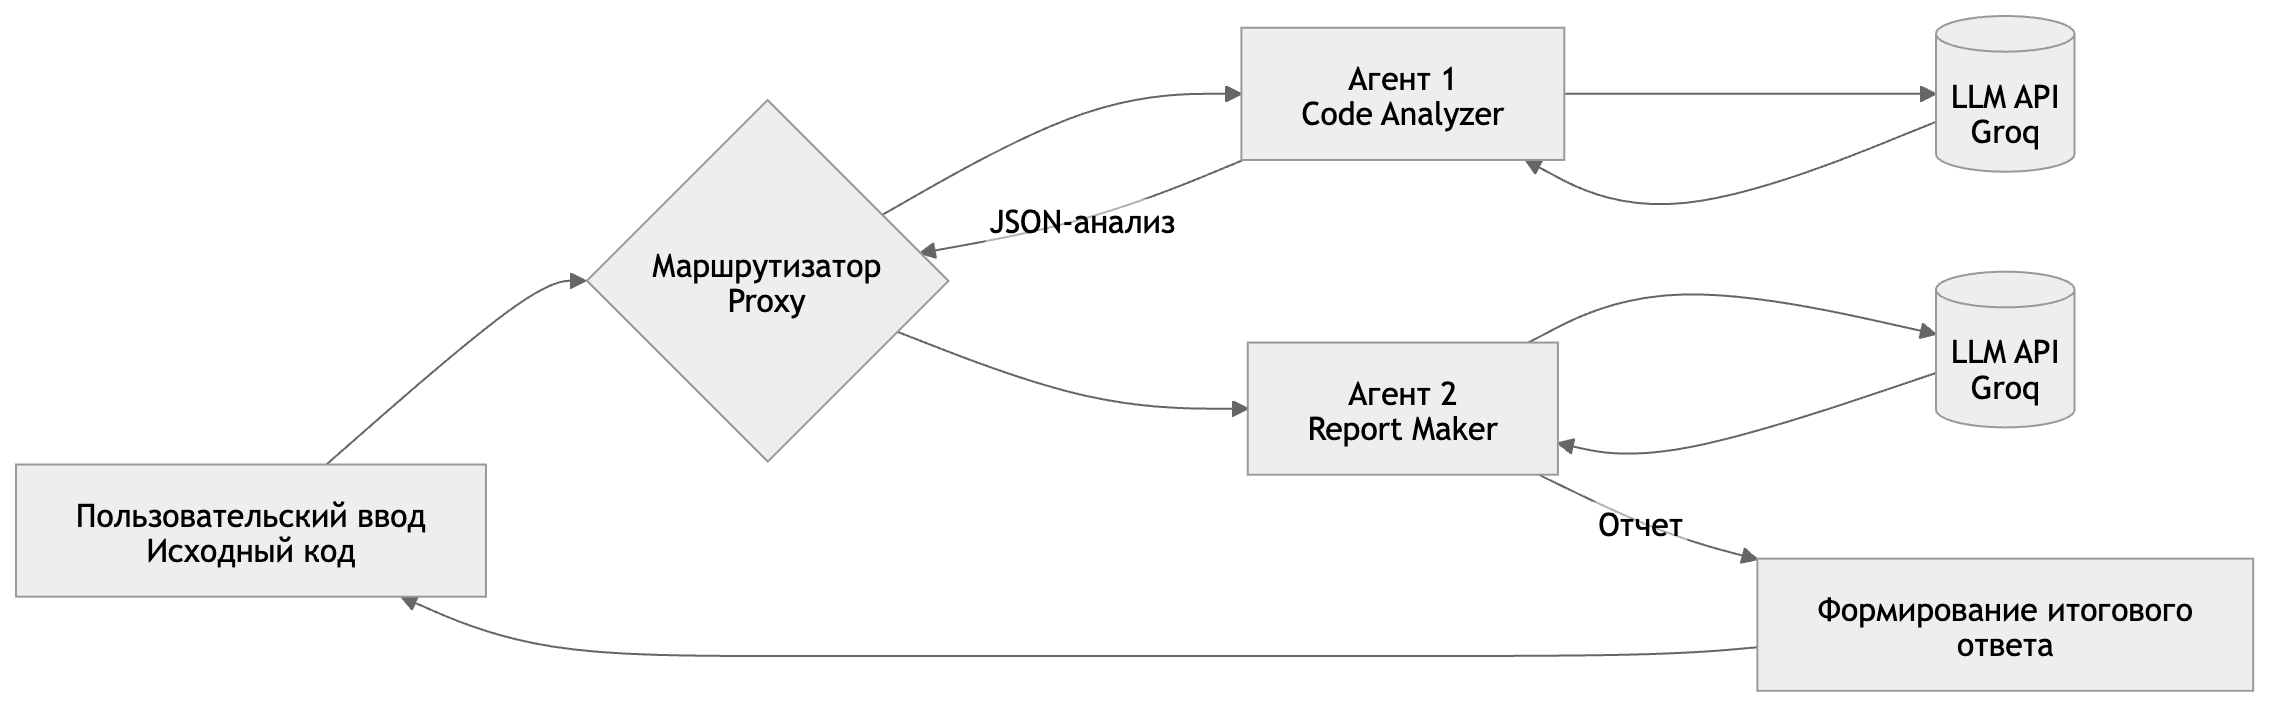